# COGS 108 - EDA Checkpoint

## Authors

- Mia Mayer: Conceptualization, Project administration, Writing – review & editing
- Julia Visaya: Data curation, Software, Writing – review & editing
- Hemi Kim: Analysis, Data curation, Software, Visualization, Writing – original draft
- Katelyn Ma: Background research, Writing – review & editing
- Catherine Do: Background research, Writing – original draft

## Research Question

Is there a statistically significant association between institutional funding levels at U.S. public colleges and the median annual earnings of graduates approximately ten years after enrollment?

Funding will be measured using institution-level financial variables such as total revenue, instructional expenditures, and state and federal appropriations obtained from IPEDS/NCES. Graduate outcomes will be measured using the College Scorecard median earnings metric at approximately ten years after completion.

To account for potential confounding factors, we will include controls for institutional scale (enrollment and completions), geographic variation (state/region), and regional cost-of-living proxies (ACS median household income). This is a statistical inference project using correlation and regression analyses.

## Background and Prior Work

The funding of public higher education remains a central topic in debates regarding economic advancement, workforce outcomes, and the promotion of financial mobility in the United States. Public colleges and universities educate a significant proportion of the nation’s working population, as they receive financial backing from an integration of state support, tuition revenue, and federal funding.<a id="cite_ref-1"></a>[<sup>1</sup>](#cite_note-1) However, this degree of funding varies across public college and university districts as a result of differences in state budgets, enrollment rates, and regional economic priorities.<a id="cite_ref-2"></a>[<sup>2</sup>](#cite_note-2) These variations motivate our question of whether greater financial investment in higher education systems is associated with stronger long-term economic outcomes for graduates.

To study this relationship, we plan to use publicly available administrative datasets from the National Center for Education Statistics (NCES) and related federal education data systems. From NCES, we extracted or identified datasets that capture: (1) median earnings of graduates<a id="cite_ref-6"></a>[<sup>6</sup>](#cite_note-6), (2) institutional funding and revenue, (3) tuition and cost of attendance, (4) enrollment and completions, and (5) institutional characteristics such as location and size.<a id="cite_ref-3"></a>[<sup>3</sup>](#cite_note-3) Together, these datasets allow us to examine how funding levels relate to graduate earnings while accounting for institutional scale and geographic differences.

A key concern in comparing earnings across institutions is that similar salaries can imply different standards of living depending on local costs and regional economic conditions. To further contextualize earnings outcomes, we incorporate cost-of-living information using socioeconomic data from the U.S. Census Bureau (American Community Survey), enabling a more accurate comparison of earnings across regions by using a regional proxy such as median household income.<a id="cite_ref-4"></a>[<sup>4</sup>](#cite_note-4)

This project also connects to prior work that evaluates the economic value of higher education, including student earnings outcomes and the opportunity costs of attending college. A previous COGS 108 project (“Are Universities Worth the Opportunity Cost?”) provides a relevant methodological reference for analyzing education-related economic outcomes using institutional-level data, and it motivates our emphasis on measurable labor market outcomes in a rigorous, data-driven framework.<a id="cite_ref-5"></a>[<sup>5</sup>](#cite_note-5)

---

1. <a id="cite_note-1"></a> [^](#cite_ref-1) National Center for Education Statistics (NCES). *Digest of Education Statistics*. https://nces.ed.gov/programs/digest/
2. <a id="cite_note-2"></a> [^](#cite_ref-2) NCES Condition of Education — Postsecondary Institution Revenue. https://nces.ed.gov/programs/coe/indicator/cud/postsecondary-institution-revenue
3. <a id="cite_note-3"></a> [^](#cite_ref-3) Integrated Postsecondary Education Data System (IPEDS) — Survey Components and Data Center. https://nces.ed.gov/ipeds/
4. <a id="cite_note-4"></a> [^](#cite_ref-4) U.S. Census Bureau — American Community Survey (ACS) Data Tables (including B19013). https://data.census.gov/ ; https://data.census.gov/table/ACSDT5Y2022.B19013
5. <a id="cite_note-5"></a> [^](#cite_ref-5) Previous COGS 108 Project (Sp17): *Are Universities Worth the Opportunity Cost?* https://github.com/COGS108/FinalProjects-Sp17/blob/master/081-FinalProject.ipynb
6. <a id="cite_note-6"></a> [^](#cite_ref-6) College Scorecard — Data Documentation and Bulk Downloads (median earnings). https://collegescorecard.ed.gov/data/


## Hypothesis

We predict a positive association between institutional funding per student and median earnings ten years after entry. Higher funding may allow institutions to provide better academic and career resources that improve students’ long-term earning potential. Because earnings vary substantially by major, we will control for the types of degrees offered at each institution. Specifically, we will include measures of degree composition (e.g., the proportion of graduates in higher-paying fields such as engineering, computer science, health, or business) using data from the College Scorecard. This helps ensure that any observed relationship between funding and earnings is not simply due to certain schools offering more high-paying majors. We expect funding to remain positively associated with earnings even after accounting for institutional size, geography, and degree mix.


## Data

### Data Overview

### Dataset #1: Merged IPEDS Finance and College Scorecard Earnings (2012)

- **Dataset Name:** Merged IPEDS finance/enrollment data with College Scorecard earnings (2012 cohort)
- **Link:** https://nces.ed.gov/ipeds/use-the-data (Compare Institutions tool)
- **Number of observations:** 636 institutions
- **Number of variables:** 5

**Key variables:**
- `UNITID` — institutional identifier used for merging datasets
- `instruction_exp_2012` — instructional expenditures reported for fiscal year 2012 (USD)
- `enrollment_2012` — total fall enrollment for 2012
- `funding_per_student_2012` — instructional expenditures per student (computed as instructional expenditures divided by enrollment)
- `MD_EARN_WNE_P10` — median earnings of students approximately 10 years after entry (College Scorecard metric)

**Shortcomings:**
- Institutional finance totals scale with institution size, making raw expenditure values difficult to compare across institutions. We address this by computing instructional spending per student.
- Earnings outcomes may be influenced by factors such as institutional selectivity, program mix, or regional labor markets, which are not fully captured in this dataset.



### Dataset #2: College Scorecard Geographic Identifiers (2012–13 Cohort)

- **Dataset Name:** College Scorecard cohort file `MERGED2012_13_PP.csv`
- **Link:** https://collegescorecard.ed.gov/data/ (bulk download archive)
- **Number of observations:** 7,862 institutions in the raw dataset
- **Number of variables:** 3,306 variables in the full dataset; we extract a small subset

**Key variables used:**
- `UNITID` — institution identifier used for merging
- `STABBR` — state abbreviation
- `REGION` — U.S. Census region identifier

**Shortcomings:**
- The full Scorecard dataset contains thousands of variables, many of which are not relevant to this analysis.
- Some geographic fields may contain missing values depending on institutional reporting.



### Dataset #3: American Community Survey (ACS) Median Household Income (2012)

- **Dataset Name:** ACS 5-Year Estimates (2012), Table B19013 (Median Household Income)
- **Link:** https://data.census.gov/
- **Unit of observation:** U.S. state (plus District of Columbia)
- **Number of observations:** 52 after cleaning
- **Number of variables used:** 2

**Key variables:**
- `STABBR` — state abbreviation used for merging
- `median_household_income` — median household income (USD), used as a proxy for regional economic conditions and cost of living

**Processing notes:**
- The table export from data.census.gov is provided in wide format. We convert it to a long table and map state names to postal abbreviations (`STABBR`) using a preprocessing helper (`modules/acs_processing.py`).
- U.S. territories not included in the ACS state table (AS, MP, GU, VI) are excluded from analyses that use this regional socioeconomic proxy.

**Shortcomings:**
- Median household income is an imperfect proxy for cost of living and local labor market conditions.
- State-level aggregation may not capture within-state variation around each institution.



### Combining datasets

Datasets are merged using the institutional identifier `UNITID`. We compute an institutional funding measure comparable across schools by calculating instructional spending per student:

`funding_per_student_2012 = instructional_expenditures_2012 / enrollment_2012`.

The merged institutional dataset is then augmented with geographic identifiers extracted from the College Scorecard data. These identifiers allow us to incorporate ACS median household income as a regional socioeconomic control variable.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("./modules")

### Dataset #1: Merged IPEDS Funding and College Scorecard Earnings Dataset

This dataset contains institutional-level data linking IPEDS funding information with College Scorecard graduate earnings outcomes. The dataset was created in the Data Checkpoint by merging IPEDS finance and enrollment data with College Scorecard median earnings using the institutional identifier `UNITID`.

The dataset includes funding measures, enrollment counts, and median earnings approximately ten years after entry. We verify the dataset structure and cleanliness below before proceeding with exploratory analysis.

In [2]:
import pandas as pd

ipeds = pd.read_csv("data/02-processed/funding_earnings_2012_processed.csv")

ipeds.shape

(636, 5)

In [3]:
ipeds.head()

,UNITID,instruction_exp_2012,enrollment_2012,funding_per_student_2012,MD_EARN_WNE_P10
0,138558,10812772.0,3233.0,3344.501083,32000.0
1,126182,20371768.0,3290.0,6192.026748,32800.0
2,100654,37967292.0,4853.0,7823.468370,30300.0
3,100724,42848156.0,5816.0,7367.289546,26600.0
4,138716,28153311.0,4275.0,6585.569825,31500.0


In [4]:
ipeds.info()

<class 'pandas.DataFrame'>
RangeIndex: 636 entries, 0 to 635
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   UNITID                    636 non-null    int64  
 1   instruction_exp_2012      636 non-null    float64
 2   enrollment_2012           636 non-null    float64
 3   funding_per_student_2012  636 non-null    float64
 4   MD_EARN_WNE_P10           636 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 25.0 KB


In [5]:
ipeds.describe()

,UNITID,instruction_exp_2012,enrollment_2012,funding_per_student_2012,MD_EARN_WNE_P10
count,636.000000,6.360000e+02,636.000000,636.000000,636.000000
mean,183637.044025,1.070996e+08,12301.767296,9329.452891,41747.327044
std,49891.754087,1.523262e+08,11588.545259,14888.693575,17210.897731
min,100654.000000,0.000000e+00,205.000000,0.000000,17200.000000
25%,148434.500000,2.243064e+07,3767.500000,5009.187282,34100.000000
50%,184955.500000,5.411952e+07,8293.000000,6399.944574,39000.000000
75%,216219.500000,1.217680e+08,16994.250000,8645.596036,44425.000000
max,451671.000000,1.450832e+09,73378.000000,253742.803630,219900.000000


In [6]:
ipeds.isna().sum()

UNITID                      0
instruction_exp_2012        0
enrollment_2012             0
funding_per_student_2012    0
MD_EARN_WNE_P10             0
dtype: int64

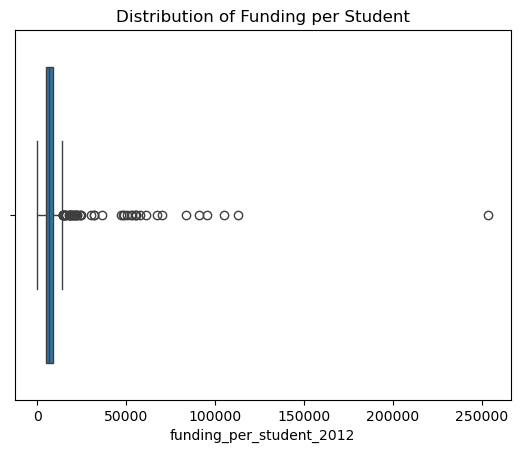

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=ipeds["funding_per_student_2012"])
plt.title("Distribution of Funding per Student")
plt.show()

The distribution of funding per student is right-skewed, with a small number of institutions showing extremely high values. Inspection of these observations suggests that they arise from institutions with high instructional expenditures relative to small enrollment sizes. Because these values represent real institutional differences rather than data errors, they are retained for further analysis.

In [8]:
ipeds.duplicated(subset="UNITID").sum()

np.int64(0)

### Dataset #2: College Scorecard Geographic Identifiers

This dataset extracts geographic identifiers from the College Scorecard cohort file (`MERGED2012_13_PP.csv`). 
These variables provide institutional location information, including state and region (e.g., `STABBR`, `REGION`), which will later be used to merge institutional data with regional socioeconomic indicators from the American Community Survey (ACS). The cleaned geographic subset was generated during preprocessing and is loaded from the processed data directory.

In [9]:
import sys
sys.path.append("./modules")

from scorecard_geo import extract_geo

scorecard_geo = extract_geo("data/00-raw/MERGED2012_13_PP.csv")

scorecard_geo.head()

,UNITID,STABBR,REGION
0,100636,AL,0
1,100654,AL,5
2,100663,AL,5
3,100690,AL,5
4,100706,AL,5


In [10]:
scorecard_geo.shape
scorecard_geo.isna().sum()

UNITID    0
STABBR    0
REGION    0
dtype: int64

In [11]:
scorecard_geo.duplicated(subset="UNITID").sum()

np.int64(0)

### Dataset #3: American Community Survey (ACS) Median Household Income (2012)

This dataset contains state-level median household income estimates from the U.S. Census Bureau’s American Community Survey (ACS) 5-Year Estimates (2012).

The unit of observation is the state.

Key variable used:
- `median_household_income`: Median household income (USD) for each U.S. state and the District of Columbia.

The dataset was downloaded directly from data.census.gov (Table B19013: Median Household Income in the Past 12 Months) and converted from wide format to long format during preprocessing using helper functions in `modules/acs_processing.py`. State names were mapped to standard postal abbreviations (`STABBR`) to align with the College Scorecard dataset.

Territories not included in the ACS state table (AS, MP, GU, VI) were excluded from analyses requiring this regional socioeconomic proxy. that serves as a proxy for differences in cost of living across states.

In [12]:
acs_income = pd.read_csv("data/02-processed/acs_median_income_2012_long.csv")

acs_income.head()

,STABBR,median_household_income
0,AL,41574.0
1,AK,67712.0
2,AZ,47826.0
3,AR,40112.0
4,CA,58328.0


In [13]:
acs_income.shape
acs_income.info()

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   STABBR                   52 non-null     str    
 1   median_household_income  52 non-null     float64
dtypes: float64(1), str(1)
memory usage: 964.0 bytes


In [14]:
acs_income.isna().sum()

STABBR                     0
median_household_income    0
dtype: int64

In [15]:
acs_income.duplicated(subset="STABBR").sum()

np.int64(0)

The ACS dataset contains state-level median household income estimates for 2012. Each observation corresponds to a U.S. state identified by its abbreviation (`STABBR`). This variable allows us to merge institutional data with regional socioeconomic information that may influence graduate earnings outcomes.

### Data Merging and Final Analytic Dataset

After preparing the three datasets described above, we merge them to construct the final analytic dataset used for exploratory analysis.

First, the institutional funding and earnings dataset (Dataset #1) is merged with the College Scorecard geographic identifiers (Dataset #2) using the institutional identifier `UNITID`. This step adds institutional location information such as state abbreviation (`STABBR`) and Census region (`REGION`) to each observation.

Next, the resulting dataset is merged with the ACS median household income dataset (Dataset #3) using the state abbreviation (`STABBR`). This step attaches a state-level socioeconomic indicator to each institution, which serves as a proxy for regional economic conditions.

The final merged dataset contains institutional funding measures, graduate earnings outcomes, geographic identifiers, and regional income data. This combined dataset forms the basis for the exploratory data analysis that follows.

In [16]:
merged = ipeds.merge(
    scorecard_geo,
    on="UNITID",
    how="left"
)

merged.head()

,UNITID,instruction_exp_2012,enrollment_2012,funding_per_student_2012,MD_EARN_WNE_P10,STABBR,REGION
0,138558,10812772.0,3233.0,3344.501083,32000.0,GA,5
1,126182,20371768.0,3290.0,6192.026748,32800.0,CO,7
2,100654,37967292.0,4853.0,7823.468370,30300.0,AL,5
3,100724,42848156.0,5816.0,7367.289546,26600.0,AL,5
4,138716,28153311.0,4275.0,6585.569825,31500.0,GA,5


In [17]:
merged.shape

(636, 7)

In [18]:
merged.isna().sum()

UNITID                      0
instruction_exp_2012        0
enrollment_2012             0
funding_per_student_2012    0
MD_EARN_WNE_P10             0
STABBR                      0
REGION                      0
dtype: int64

In [19]:
merged = merged.merge(
    acs_income,
    on="STABBR",
    how="left"
)

merged.head()

,UNITID,instruction_exp_2012,enrollment_2012,funding_per_student_2012,MD_EARN_WNE_P10,STABBR,REGION,median_household_income
0,138558,10812772.0,3233.0,3344.501083,32000.0,GA,5,47209.0
1,126182,20371768.0,3290.0,6192.026748,32800.0,CO,7,56765.0
2,100654,37967292.0,4853.0,7823.468370,30300.0,AL,5,41574.0
3,100724,42848156.0,5816.0,7367.289546,26600.0,AL,5,41574.0
4,138716,28153311.0,4275.0,6585.569825,31500.0,GA,5,47209.0


In [20]:
merged.shape
merged.isna().sum()

UNITID                      0
instruction_exp_2012        0
enrollment_2012             0
funding_per_student_2012    0
MD_EARN_WNE_P10             0
STABBR                      0
REGION                      0
median_household_income     4
dtype: int64

A small number of institutions have missing ACS income values after merging (e.g., institutions in territories or unmatched state codes); these rows are retained for analyses that do not require the ACS control.

In [21]:
merged.duplicated(subset="UNITID").sum()

np.int64(0)

In [22]:
merged.describe()

,UNITID,instruction_exp_2012,enrollment_2012,funding_per_student_2012,MD_EARN_WNE_P10,REGION,median_household_income
count,636.000000,6.360000e+02,636.000000,636.000000,636.000000,636.000000,632.000000
mean,183637.044025,1.070996e+08,12301.767296,9329.452891,41747.327044,4.547170,50906.530063
std,49891.754087,1.523262e+08,11588.545259,14888.693575,17210.897731,2.027987,8083.327052
min,100654.000000,0.000000e+00,205.000000,0.000000,17200.000000,0.000000,19429.000000
25%,148434.500000,2.243064e+07,3767.500000,5009.187282,34100.000000,3.000000,45076.000000
50%,184955.500000,5.411952e+07,8293.000000,6399.944574,39000.000000,5.000000,49760.000000
75%,216219.500000,1.217680e+08,16994.250000,8645.596036,44425.000000,6.000000,56448.000000
max,451671.000000,1.450832e+09,73378.000000,253742.803630,219900.000000,9.000000,71122.000000


In [23]:
merged.to_csv(
    "data/02-processed/funding_earnings_geo_income_2012.csv",
    index=False
)

We merge the institutional funding and earnings dataset with geographic identifiers extracted from the College Scorecard using the shared institutional identifier `UNITID`. The resulting dataset is then merged with ACS state-level median household income using the state abbreviation (`STABBR`). 

This produces a combined institutional dataset containing measures of funding, graduate earnings outcomes, and regional socioeconomic indicators that will be used in the exploratory data analysis.

## Results

### Exploratory Data Analysis

To better understand the structure of the data and evaluate our research question, we begin with exploratory data analysis. We first examine the distributions of key variables, including instructional funding per student and median earnings ten years after entry. We then visualize the relationship between these variables and investigate potential outliers that may affect interpretation. Finally, we explore correlations among variables and examine regional patterns in earnings outcomes.

In [24]:
merged.shape

(636, 8)

The merged dataset contains 636 institutions with complete institutional funding and earnings data.

#### Distribution of Funding

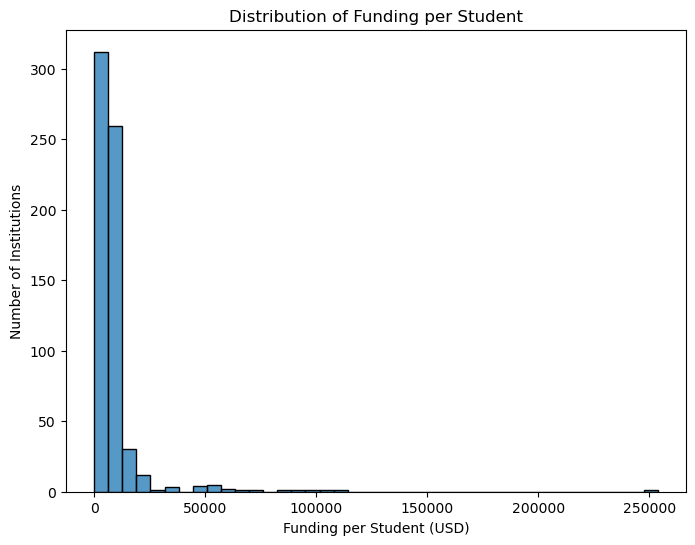

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.histplot(merged["funding_per_student_2012"], bins=40)
plt.title("Distribution of Funding per Student")
plt.xlabel("Funding per Student (USD)")
plt.ylabel("Number of Institutions")
plt.show()

Instructional funding per student is strongly right-skewed. Most institutions spend between roughly 3,000 and 15,000 USD per student, while a small number of institutions report much higher spending levels. These extreme values likely reflect specialized institutions with large instructional budgets and relatively small enrollments, which inflates the per-student spending measure.

#### Distribution of Earnings

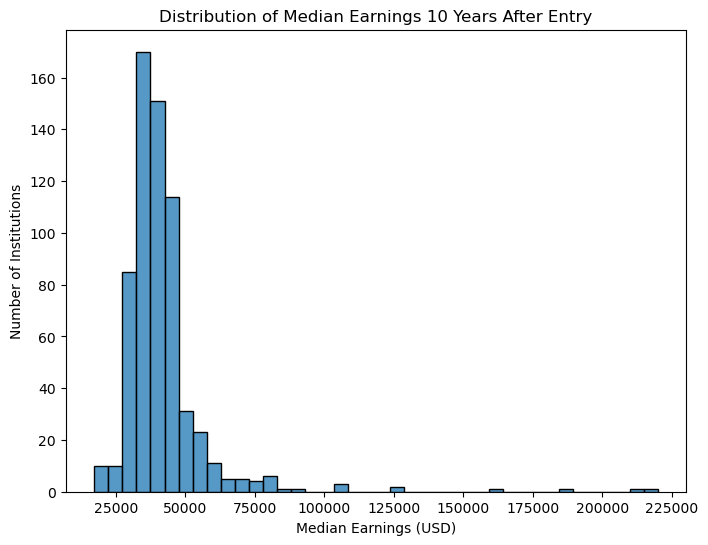

In [26]:
plt.figure(figsize=(8,6))
sns.histplot(merged["MD_EARN_WNE_P10"], bins=40)
plt.title("Distribution of Median Earnings 10 Years After Entry")
plt.xlabel("Median Earnings (USD)")
plt.ylabel("Number of Institutions")
plt.show()

Median earnings ten years after entry also exhibit a right-skewed distribution. Most institutions have graduate earnings between approximately 30,000 and 50,000 USD, while a small number of institutions report substantially higher earnings outcomes. These higher values likely reflect highly selective institutions or specialized programs associated with higher-paying career paths.

#### Funding per Student vs Median Graduate Earnings

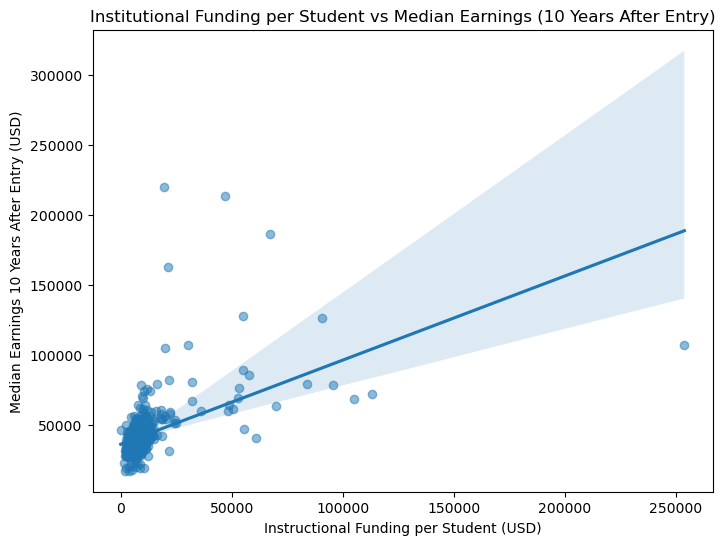

In [27]:
from modules.eda_utils import regplot

regplot(
    merged,
    x="funding_per_student_2012",
    y="MD_EARN_WNE_P10",
    title="Institutional Funding per Student vs Median Earnings (10 Years After Entry)",
    xlabel="Instructional Funding per Student (USD)",
    ylabel="Median Earnings 10 Years After Entry (USD)"
)

The scatter plot suggests a positive relationship between instructional spending per student and median earnings ten years after entry. Institutions with higher instructional funding per student tend to be associated with higher graduate earnings outcomes. However, the relationship is difficult to interpret clearly in the raw scale because a small number of institutions with extremely high spending values compress the majority of observations toward the lower end of the funding axis.

In [28]:
merged.loc[merged["funding_per_student_2012"] == 0]

,UNITID,instruction_exp_2012,enrollment_2012,funding_per_student_2012,MD_EARN_WNE_P10,STABBR,REGION,median_household_income
426,187046,0.0,20606.0,0.0,46600.0,NJ,2,69667.0


In [29]:
merged.nlargest(5, "funding_per_student_2012")

,UNITID,instruction_exp_2012,enrollment_2012,funding_per_student_2012,MD_EARN_WNE_P10,STABBR,REGION,median_household_income
564,228635,615072556.0,2424.0,253742.803630,106900.0,TX,6,50740.0
421,228644,367377877.0,3249.0,113074.138812,72100.0,TX,6,50740.0
423,228653,316429859.0,3012.0,105056.394090,68300.0,TX,6,50740.0
420,229300,428754661.0,4489.0,95512.288037,78700.0,TX,6,50740.0
454,110699,284609000.0,3137.0,90726.490277,126500.0,CA,8,58328.0


In [30]:
scorecard = pd.read_csv("data/00-raw/MERGED2012_13_PP.csv", low_memory=False)

scorecard.loc[
    scorecard["UNITID"].isin([228635,228644,228653,229300,110699]),
    ["UNITID","INSTNM","STABBR"]
]

,UNITID,INSTNM,STABBR
260,110699,University of California-San Francisco,CA
3931,228635,University of Texas Southwestern Medical Center,TX
3932,228644,The University of Texas Health Science Center ...,TX
3933,228653,The University of Texas Medical Branch at Galv...,TX
3958,229300,The University of Texas Health Science Center ...,TX


Inspection of the data reveals that one institution reports zero instructional expenditures, which likely reflects missing financial reporting rather than a meaningful value. In addition, a small number of specialized medical institutions report extremely high spending per student due to large budgets and relatively small enrollments. These values create strong right-skew in the funding distribution and obscure the underlying relationship between funding and earnings. To better visualize the relationship across most institutions, we examine the variables using log-transformed values.

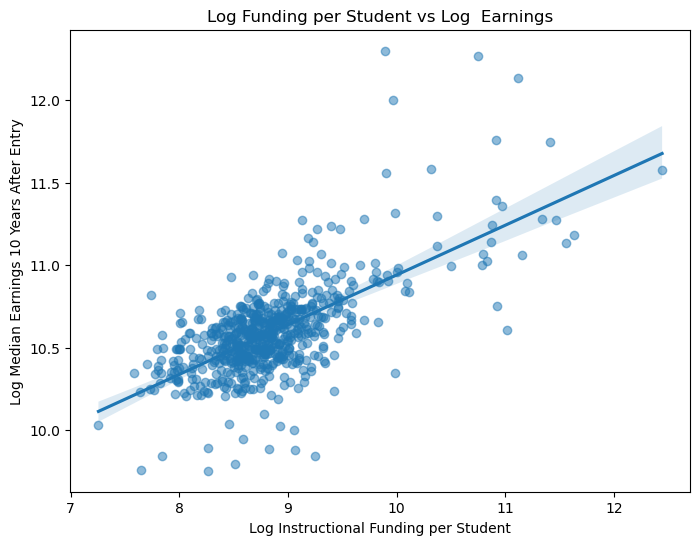

In [31]:
merged_clean = merged[merged["funding_per_student_2012"] > 0].copy()

import numpy as np

merged_clean["log_funding"] = np.log1p(merged_clean["funding_per_student_2012"])
merged_clean["log_earnings"] = np.log1p(merged_clean["MD_EARN_WNE_P10"])

from modules.eda_utils import regplot

regplot(
    merged_clean,
    x="log_funding",
    y="log_earnings",
    title="Log Funding per Student vs Log  Earnings",
    xlabel="Log Instructional Funding per Student",
    ylabel="Log Median Earnings 10 Years After Entry"
)

Log transformation reduces the influence of extreme outliers and makes the underlying relationship between funding and earnings easier to observe. Institutions with higher instructional spending per student tend to exhibit somewhat higher earnings outcomes among graduates, though substantial variability remains across institutions.

#### Correlation 

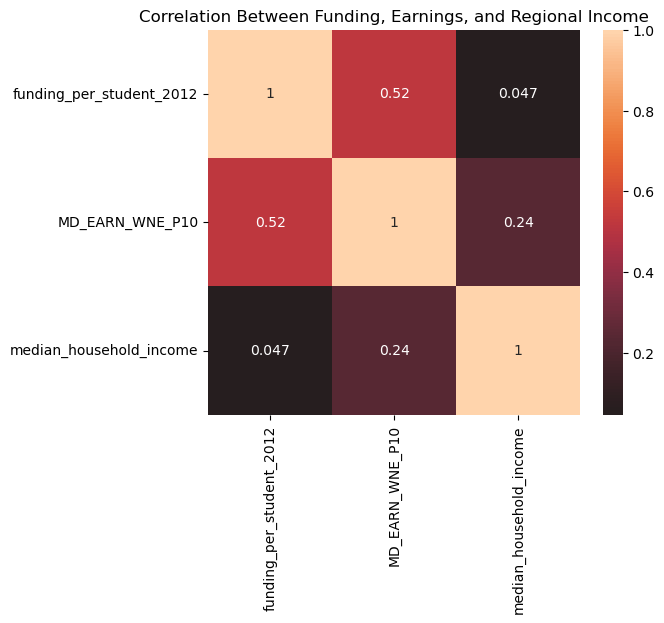

In [32]:
from modules.eda_utils import heatmap_corr

heatmap_corr(
    merged,
    ["funding_per_student_2012", "MD_EARN_WNE_P10", "median_household_income"],
    title="Correlation Between Funding, Earnings, and Regional Income"
)

The correlation matrix shows a moderate positive correlation (≈0.52) between instructional funding per student and graduate earnings. This suggests that institutions with higher instructional spending tend to be associated with higher graduate earnings, although correlation alone does not imply causation.

#### Earnings by Region

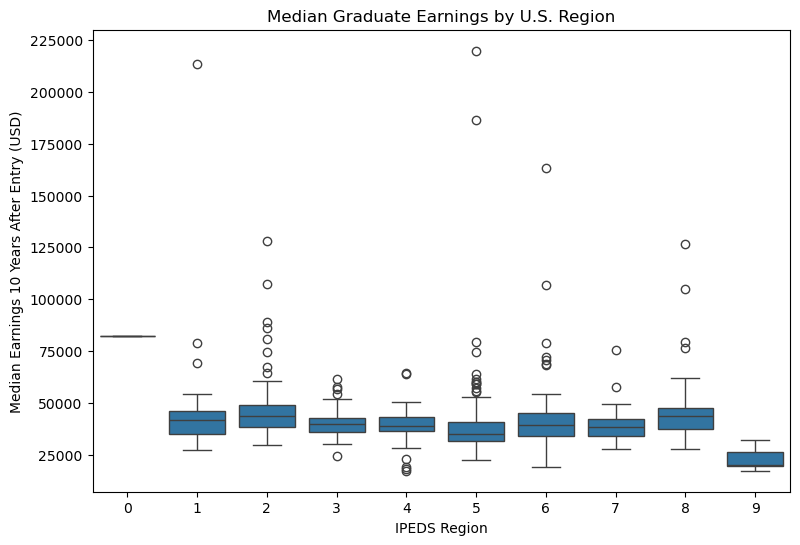

In [33]:
plt.figure(figsize=(9,6))

sns.boxplot(
    x="REGION",
    y="MD_EARN_WNE_P10",
    data=merged
)

plt.title("Median Graduate Earnings by U.S. Region")
plt.xlabel("IPEDS Region")
plt.ylabel("Median Earnings 10 Years After Entry (USD)")
plt.show()

This boxplot shows the distribution of median graduate earnings across IPEDS geographic regions. Regional variation in earnings may reflect differences in local labor markets, industry composition, and cost of living.

Because institutional outcomes are influenced by regional economic conditions, geographic controls may be important when evaluating the relationship between institutional funding and graduate earnings.

## Ethics

### A. Data Collection
 - [X] **A.1 Informed consent**: Our project uses publicly available datasets collected by federal agencies. Since we have no direct interaction with human subjects, informed consent was handled by the original institutions under their legal and ethical frameworks.
 - [X] **A.2 Collection bias**: There may be collection bias due to how different institutions/districts report funding and how earnings are aggregated geographically. Missing or incomplete records may systematically differ from institutions with complete data. We will document missingness and interpret results cautiously.
 - [X] **A.3 Limit PII exposure**: No personally identifiable information (PII) is used in this project. All data are aggregated at the institution or regional level, preventing identification of individuals.
 - [X] **A.4 Downstream bias mitigation**: When available, variables such as race/ethnicity and gender distributions (or related composition measures) will be included to explore potential disparities in outcomes.

### B. Data Storage
 - [X] **B.1 Data security**: We rely on publicly available data sources and will avoid downloading unnecessary or sensitive data. We will keep dependencies up to date and store data in the repository only as needed for analysis.
 - [X] **B.2 Right to be forgotten**: Not applicable because we do not use PII and use only aggregated public data.
 - [X] **B.3 Data retention plan**: Not applicable because we do not store PII; we will retain only project-relevant, public, aggregated datasets.

### C. Analysis
 - [X] **C.1 Missing perspectives**: Our datasets will not fully capture contextual factors such as local job opportunities, accessibility barriers, or other community support systems. We will acknowledge these limitations in our discussion.
 - [X] **C.2 Dataset bias**: We will explicitly state that correlations may reflect broader socioeconomic forces rather than a direct causal effect of institutional funding.
 - [X] **C.3 Honest representation**: We will present visualizations and summaries that reflect the underlying data accurately and avoid misleading scales or selective reporting.
 - [X] **C.4 Privacy in analysis**: We will not use or display PII, and will only analyze aggregated measures.
 - [X] **C.5 Auditability**: Our analysis will be reproducible and documented in the notebook with clear steps for data cleaning, merging, and modeling.

### D. Modeling
 - [X] **D.1 Proxy discrimination**: We will avoid using protected attributes directly. Our models use institution-level funding rather than individual characteristics, and we include regional controls to reduce geographic variables acting as proxies for wealth demographics.
 - [X] **D.2 Fairness across groups**: We will evaluate whether model errors or residuals differ systematically across institution types (e.g., region, size), to ensure results do not consistently over- or under-estimate outcomes for particular groups of schools.
 - [X] **D.3 Metric selection**: In addition to standard model fit metrics, we will examine error distributions and uncertainty to ensure results are not misleading.
 - [X] **D.4 Explainability**: We will explain results in understandable terms (e.g., how funding and controls relate to predicted earnings) and highlight uncertainty and assumptions.
 - [X] **D.5 Communicate limitations**: We will communicate limitations in plain language, emphasizing that findings are correlational and context-dependent.

### E. Deployment
 - [X] **E.1 Monitoring and evaluation**: If we extend the project, we would check model stability with updated data releases and re-evaluate assumptions.
 - [X] **E.2 Redress**: If results could plausibly contribute to harm or misinterpretation, we will revise analysis framing and clarify limitations and responsible interpretation.
 - [X] **E.3 Roll back**: Since this is an academic analysis (not a deployed system), results can be revised or withdrawn if issues are found.
 - [X] **E.4 Unintended use**: Our findings could be misused to oversimplify debates about school funding (e.g., implying low-earning outcomes justify budget cuts). We will emphasize that results are correlational and that many unmeasured factors influence earnings beyond what we analyze.


## Team Expectations 

1. **Weekly Sync:** We aim to check in with each other through iMessage every other day while meeting in person at least once a week, transitioning to Zoom if we feel additional meeting days will be beneficial to our group progress. We expect responses to messages within 24 hours, while indicating “urgent” for urgent issues.
2. **Communication Policies:** All communication will be direct and polite. Team members will listen actively to each other, assume good intentions, and encourage everyone to participate equally in discussions. To personally suggest something, a group member should send a message like: “I think X may not work because of Y” or “I think we may need to change X to Y because of Z.”
3. **Conflict Resolution:** We plan to use majority vote for most decisions. For minor decisions such as task assignments, we believe it is more straightforward to assign authority to designated members. If a decision is time-sensitive, we will proceed with the input of responsive teammates and inform any non-responsive teammates afterward.
4. **When a member is struggling:** If a team member is struggling to complete a task, they should notify the group as soon as possible (ideally via iMessage) within 24–28 hours explaining the task and the issue. The team will assess the situation and provide guidance/resources or help break the task into smaller parts. If needed, remaining work will be redistributed to meet deadlines while keeping workload balanced. If unresolved, the team will escalate the issue to a TA or the professor.


## Project Timeline Proposal

| Meeting Date | Meeting Time | Completed Before Meeting | Discuss at Meeting |
|---|---:|---|---|
| 2/1 | 2:00 PM | Read and review COGS 108 expectations; brainstorm potential topics and research questions | Decide on primary form of communication; finalize project topic; discuss initial hypothesis; begin background research |
| 2/3 | 2:00 PM | Conduct background research on the chosen topic | Identify ideal datasets (NCES, Census); discuss ethics considerations; draft initial project proposal |
| 2/4 | 2:00 PM | Edit, finalize, and submit the project proposal | Confirm dataset choices; discuss data wrangling strategy and analytical approaches; assign group leads |
| 2/14 | 2:00 PM | Import, merge, and format datasets; complete initial data cleaning | Review data wrangling progress; address data issues; plan remaining cleaning steps |
| 2/18 | No meeting (Checkpoint) | Checkpoint #1: Data — finalize datasets and complete initial cleaning | N/A |
| 2/23 | 2:00 PM | Finalize cleaned datasets; begin exploratory analysis | Review early EDA results; refine analysis plan; prepare for EDA checkpoint |
| 3/4 | No meeting (Checkpoint) | Checkpoint #2: EDA — complete EDA and generate initial visualizations | N/A |
| 3/13 | 2:00 PM | Complete statistical analysis; draft results and discussion sections | Review and edit full project draft; plan final revisions |
| 3/18 | Before 11:59 PM | Final Submission — Jupyter Notebook and 3–5 minute video | N/A |